# 📦 04 · 目标检测

> 目标：从「分类整图」跨到「框出每个物体并给类别」。手写 **IoU/GIoU、NMS、YOLO v1 编解码、mAP 评估**，
> 把 R-CNN 两阶段与 YOLO 一阶段的思路彻底讲清。

> 🧩 **生活化类比**：分类是「看到一桌菜说出菜名」，检测是「在菜谱照片里圈出每一道菜并标注」。
> 圈得准不准用 IoU（两个框重叠度）打分，重复圈同一道菜用 NMS 合并。


## 1. 任务定义与评价思路

- **检测 = 分类 + 定位**：输出一组 $(x_1, y_1, x_2, y_2, \\text{class}, \\text{conf})$ 框
- 与分类的区别：物体数量不定、位置不定、可重叠
- 评价两个维度：**框准不准（IoU）** 与 **分对没有（类别+置信度排序）**

| 术语 | 含义 |
|------|------|
| GT / Prediction | 真值框 / 预测框 |
| TP / FP / FN | 匹配上的预测 / 误检 / 漏检 |
| Precision | TP/(TP+FP)：检出来的有多少是对的 |
| Recall | TP/(TP+FN)：真的有多少被检出来 |


## 2. IoU 与它的变体：GIoU / DIoU / CIoU

$$\\text{IoU} = \\frac{|A \\cap B|}{|A \\cup B|} = \\frac{\\text{inter}}{a_1 + a_2 - \\text{inter}}$$

- IoU 缺点：**不相交时恒为 0**，梯度消失；对框尺寸不敏感
- **GIoU**：$\\text{GIoU} = \\text{IoU} - \\dfrac{|C \\setminus (A\\cup B)|}{|C|}$（$C$ 为最小外接框），不相交也能给梯度，$\\in[-1,1]$
- **DIoU**：在 GIoU 上再加**中心点距离**惩罚：$\\text{DIoU} = \\text{IoU} - \\dfrac{\\rho^2(b,b^{gt})}{c^2}$
- **CIoU**：再考虑**长宽比**一致性（YOLOv4/v5 默认回归损失）


In [1]:
# ---------- 实验 1：手写 IoU / GIoU + 边界案例 ----------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(42)

def iou(b1, b2):
    # b = (x1, y1, x2, y2)
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    return inter / (a1 + a2 - inter + 1e-9)

def inter_area(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def giou(b1, b2):
    i = iou(b1, b2)
    x1, y1 = min(b1[0], b2[0]), min(b1[1], b2[1])
    x2, y2 = max(b1[2], b2[2]), max(b1[3], b2[3])
    area_c = (x2 - x1) * (y2 - y1) + 1e-9          # 最小外接框面积 C
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    union = a1 + a2 - inter_area(b1, b2)
    return i - (area_c - union) / area_c

# 测试案例
cases = [('部分重叠', (10, 10, 40, 40), (25, 25, 60, 60)),
         ('完全包含', (10, 10, 50, 50), (20, 20, 30, 30)),
         ('完全重合', (10, 10, 40, 40), (10, 10, 40, 40)),
         ('不相交',   (10, 10, 30, 30), (50, 50, 80, 80))]
for name, b1, b2 in cases:
    print('%-6s IoU=%.3f  GIoU=%.3f' % (name, iou(b1, b2), giou(b1, b2)))
assert np.isclose(iou((10, 10, 40, 40), (10, 10, 40, 40)), 1.0)
assert np.isclose(iou((10, 10, 30, 30), (50, 50, 80, 80)), 0.0)
print('要点：不相交时 IoU=0 无梯度；GIoU 用最小外接框 C 补出梯度（-1 ~ 1）')


部分重叠   IoU=0.118  GIoU=-0.122
完全包含   IoU=0.062  GIoU=0.062
完全重合   IoU=1.000  GIoU=1.000
不相交    IoU=0.000  GIoU=-0.735
要点：不相交时 IoU=0 无梯度；GIoU 用最小外接框 C 补出梯度（-1 ~ 1）


## 3. NMS：非极大值抑制（手撕高频题）

同一物体可能被预测出多个重叠框，NMS 按置信度从高到低留一个：

1. 按置信度降序排序
2. 取最高分框，删掉与它 IoU > 阈值的框
3. 重复直到没有框

- 阈值经验：0.5（Pascal）~ 0.7（COCO 更严）
- **Soft-NMS**：不硬删，把重叠框分数乘以 $e^{-\\text{IoU}^2/\\sigma}$ 衰减（密集目标友好）
- **NMS 为什么不能并行**：结果依赖顺序，现代用 Faster-NMS / 矩阵化加速


NMS 保留索引: [np.int64(0), np.int64(2), np.int64(3)] （应保留 A、C 与 D；B 与 A 重叠 >0.5 被抑制）


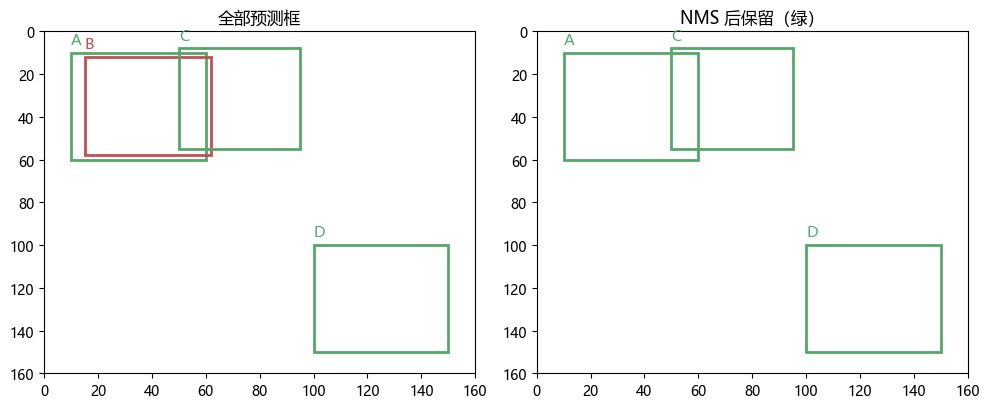

B 被抑制原因：B 与 A 的 IoU = 0.799 > 0.5；C 与 A 仅 0.108，保留


In [2]:
# ---------- 实验 2：手写 NMS + 可视化 ----------
def nms(boxes, scores, iou_thr=0.5):
    idx = np.argsort(-scores)
    keep = []
    while len(idx) > 0:
        i = idx[0]
        keep.append(i)
        rest = idx[1:]
        ious = np.array([iou(boxes[i], boxes[j]) for j in rest])
        idx = rest[ious <= iou_thr]
    return keep

# 构造 4 个框：A/B 重叠同一物体，C 略偏，D 独立
boxes = np.array([[10, 10, 60, 60], [15, 12, 62, 58], [50, 8, 95, 55], [100, 100, 150, 150]], dtype=float)
scores = np.array([0.92, 0.85, 0.70, 0.60])
keep = nms(boxes, scores, iou_thr=0.5)
print('NMS 保留索引:', keep, '（应保留 A、C 与 D；B 与 A 重叠 >0.5 被抑制）')
assert set(keep) == {0, 2, 3}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, kept_only in [(axes[0], False), (axes[1], True)]:
    ax.set_xlim(0, 160); ax.set_ylim(0, 160); ax.invert_yaxis()
    for i, (b, s) in enumerate(zip(boxes, scores)):
        if kept_only and i not in keep:
            continue
        col = '#55A868' if i in keep else '#C44E52'
        ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                   fill=False, edgecolor=col, lw=2))
        ax.text(b[0], b[1] - 4, 'A' if i == 0 else 'B' if i == 1 else 'C' if i == 2 else 'D',
                color=col, fontsize=11)
    ax.set_title('全部预测框' if not kept_only else 'NMS 后保留（绿）')
plt.tight_layout(); plt.savefig('images/cv04_nms.png', dpi=110, bbox_inches='tight'); plt.show()
print('B 被抑制原因：B 与 A 的 IoU = %.3f > 0.5；C 与 A 仅 %.3f，保留' %
      (iou(boxes[0], boxes[1]), iou(boxes[0], boxes[2])))


## 4. Anchor 与网格：检测的空间先验

**Anchor（锚框/先验框）**：预先定义的框（不同 scale × 不同 ratio），网络预测的是「相对 anchor 的偏移」：

$$\hat{x} = a_x + d_x \\cdot a_w, \\quad \\hat{w} = a_w \\cdot e^{d_w}$$

- 为什么用 anchor：直接回归任意框坐标难收敛，给一组「起点」让回归变成小偏移
- anchor 怎么定：对训练集 GT 做 K-Means（YOLO 的做法），得常见宽高比
- 现代（YOLOv5+ / Anchor-Free）：直接预测「中心点 + 宽高」或「中心到四条边的距离」

| 范式 | 代表 | 关键思想 |
|------|------|----------|
| 两阶段 | Faster R-CNN | RPN 出候选框 → 二次分类回归 |
| 单阶段 Anchor | YOLOv2-v5 / SSD | 网格 + anchor 一次回归 |
| Anchor-Free | CenterNet / FCOS | 关键点/中心到边距离，无先验框 |


## 5. 两阶段：R-CNN → Fast → Faster

| 方法 | 候选框来源 | 分类/回归 | 痛点 |
|------|-----------|-----------|------|
| R-CNN | Selective Search（~2k 个） | 每个框单独跑 CNN | 慢（2k 次前向）、训练多阶段 |
| Fast R-CNN | Selective Search | **ROI Pooling 一次全图特征** | 候选框仍来自外部，慢在搜索 |
| Faster R-CNN | **RPN（Region Proposal Network）** | 全卷积端到端 | 首次把候选框也学出来 |

**Faster R-CNN 流程**：全图 CNN 特征 → RPN 在特征图上滑 3x3 生成 anchor 框 + 前后景分数 → 框出来前 K 个候选 → ROI Pooling 对齐 → 分类头 + 回归头。

> 面试主线：**两阶段慢但准（可二次校正）；一阶段快（一次回归）**。
> RPN 的作用 = 把「selective search 的 2k 候选」换成「可学习的几百个候选」。


## 6. 一阶段：YOLO v1 的网格回归

把图分成 $S\\times S$（v1 用 7×7）网格，每个格子负责预测：

- **中心落在该格子**的物体：$(x, y, w, h, \\text{conf})$，x/y 是相对格子的偏移，w/h 是相对整图的宽高
- 每格子预测 B 个框 + 类别分数；置信度 = 框内是否有物 × IoU

**损失** = 坐标 MSE + 宽高 MSE（开根号惩罚大框）+ 置信度 MSE（有无物体加权）+ 分类 CE。
v1 的局限：小物体/重叠物体差（一格一物）、没有多尺度。

> 面试常问：**为什么 w/h 要开根号**——对大框和小框的误差同样重视（相对误差均匀化）。


GT 框: (100,80,300,240) | 所在格子: (行 3, 列 2) | 格内偏移: (1.125, -0.500)
解码还原: (100.0, 80.0, 300.0, 240.0)  误差: 0.0000


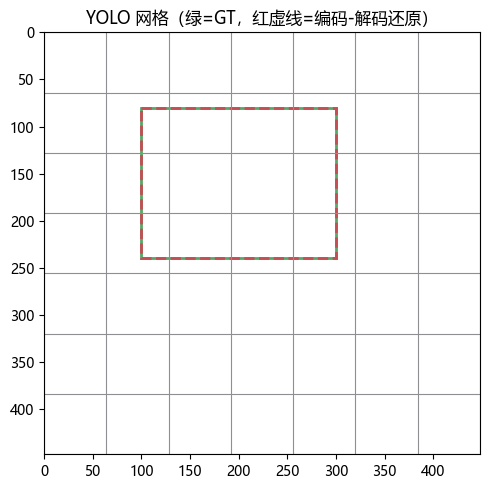

In [3]:
# ---------- 实验 3：YOLO v1 编解码手写（网格 + 相对坐标） ----------
S, IMG = 7, 448
def yolo_encode(box_abs, S=S, IMG=IMG):
    # 绝对框 (x1,y1,x2,y2) -> 网格编码 (cx_off, cy_off, w_rel, h_rel, conf)
    cx, cy = (box_abs[0] + box_abs[2]) / 2, (box_abs[1] + box_abs[3]) / 2
    w, h = box_abs[2] - box_abs[0], box_abs[3] - box_abs[1]
    gi, gj = int(cx / IMG * S), int(cy / IMG * S)       # 中心所在格子
    cx_off = (cx / IMG * S - gj)                         # 格内偏移 [0,1)
    cy_off = (cy / IMG * S - gi)
    return gi, gj, cx_off, cy_off, w / IMG, h / IMG

def yolo_decode(gi, gj, cx_off, cy_off, w_rel, h_rel, S=S, IMG=IMG):
    cx = (gj + cx_off) / S * IMG
    cy = (gi + cy_off) / S * IMG
    w, h = w_rel * IMG, h_rel * IMG
    return (cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2)

gt = (100, 80, 300, 240)
gi, gj, ox, oy, wr, hr = yolo_encode(gt)
back = yolo_decode(gi, gj, ox, oy, wr, hr)
print('GT 框: (100,80,300,240) | 所在格子: (行 %d, 列 %d) | 格内偏移: (%.3f, %.3f)' % (gi, gj, ox, oy))
print('解码还原: (%.1f, %.1f, %.1f, %.1f)  误差: %.4f' % (*back, np.abs(np.array(back) - gt).max()))
assert np.allclose(back, gt, atol=1e-3)

# 可视化：网格 + GT 中心所在格子 + 还原框
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(0, IMG); ax.set_ylim(IMG, 0)
for i in range(S + 1):
    ax.plot([i * IMG / S] * 2, [0, IMG], color='#8E8E93', lw=0.8)
    ax.plot([0, IMG], [i * IMG / S] * 2, color='#8E8E93', lw=0.8)
ax.add_patch(plt.Rectangle((gt[0], gt[1]), gt[2] - gt[0], gt[3] - gt[1], fill=False, edgecolor='#55A868', lw=2))
ax.add_patch(plt.Rectangle((back[0], back[1]), back[2] - back[0], back[3] - back[1],
                           fill=False, edgecolor='#C44E52', lw=2, ls='--'))
ax.set_title('YOLO 网格（绿=GT，红虚线=编码-解码还原）')
plt.tight_layout(); plt.savefig('images/cv04_yolo.png', dpi=110, bbox_inches='tight'); plt.show()


## 7. YOLO 演进一览（背版本）

| 版本 | 改进要点 |
|------|----------|
| v1 2016 | 网格回归开山 |
| v2 2017 | **anchor + BN + 多尺度训练**，Darknet-19 |
| v3 2018 | **多尺度特征金字塔（FPN）**、Logistic 多标签、Darknet-53 |
| v4 2020 | **CSPDarknet + PANet + Mosaic 增强 + CIoU 损失** |
| v5 2020 | 工程细节拉满（auto-anchor / 缓存 / 超参进化），至今最流行 |
| v6 2022 | 解耦头 + anchor-free 变体 |
| v8 2023 | anchor-free + 无 nms 训练（TaskAlignedAssigner） |

> 记忆主线：**anchor（v2）→ 多尺度（v3）→ 训练配方（v4/v5）→ 无锚框+解耦头（v8）**。


## 8. mAP：检测的标准评价

**AP（Average Precision）** = PR 曲线下的面积（11 点插值或积分）；**mAP** = 各类 AP 平均。

流程：
1. 预测按置信度降序；逐个判定 TP/FP（与 GT 的 IoU > 阈值且未匹配过 → TP，否则 FP；无匹配的 GT → FN）
2. 累计计算 Precision/Recall 序列 → PR 曲线 → AP
3. COCO 常用 **mAP@[0.5:0.95]**（IoU 从 0.5 到 0.95 每 0.05 算一次 AP 再平均）——对框的定位精度要求更高


mAP(@0.5) 本例 = 0.636


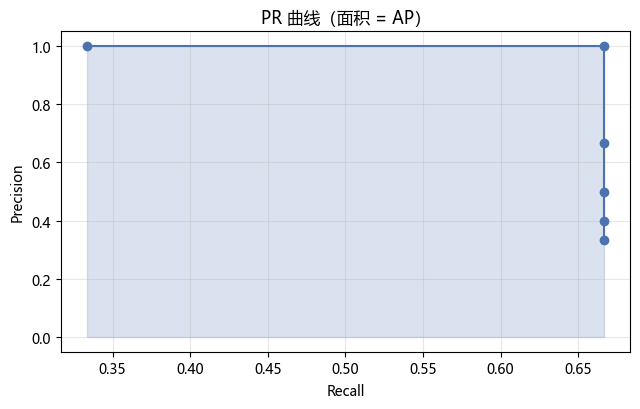

读图要点：高置信度预测先算（右→左），AP 对「排序质量」敏感——把对的排在前面才高


In [4]:
# ---------- 实验 4：手写 mAP（构造数据 + PR 曲线） ----------
def ap_from_pr(rec, prec):
    # 11 点插值 AP：对 recall 基准点 0,0.1,...,1 取该点右侧最大 precision
    ap = 0.0
    for t in np.arange(0, 1.0001, 0.1):
        mask = rec >= t
        ap += max(prec[mask]) if mask.any() else 0.0
    return ap / 11

def evaluate(dets, gts, iou_thr=0.5):
    # dets: [(score, box)]，gts: [box]；返回 PR 序列与 AP
    dets = sorted(dets, key=lambda d: -d[0])
    tp, fp = np.zeros(len(dets)), np.zeros(len(dets))
    matched = np.zeros(len(gts), dtype=bool)
    for k, (score, box) in enumerate(dets):
        best_i, best_iou = -1, 0.0
        for i, g in enumerate(gts):
            v = iou(box, g)
            if v > best_iou and not matched[i]:
                best_i, best_iou = i, v
        if best_i >= 0 and best_iou >= iou_thr:
            tp[k] = 1; matched[best_i] = True
        else:
            fp[k] = 1
    cum_tp = np.cumsum(tp); cum_fp = np.cumsum(fp)
    rec = cum_tp / len(gts)
    prec = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    return rec, prec, ap_from_pr(rec, prec)

# 构造：3 个 GT + 6 个预测（其中 3 个命中、2 个重复、1 个误检）
gts = [(20, 20, 80, 80), (120, 30, 190, 100), (40, 140, 110, 210)]
dets = [(0.95, (22, 22, 78, 78)),   # TP 命中 GT0
        (0.88, (125, 32, 188, 98)), # TP 命中 GT1
        (0.80, (60, 160, 100, 200)),# TP 命中 GT2（部分重叠）
        (0.70, (25, 20, 80, 85)),   # FP（与 GT0 重复，已匹配）
        (0.60, (300, 300, 360, 360)),# FP 误检
        (0.50, (130, 35, 185, 95))]  # FP（与 GT1 重复）
rec, prec, ap = evaluate(dets, gts, iou_thr=0.5)
print('mAP(@0.5) 本例 = %.3f' % ap)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(rec, prec, 'o-', color='#4C72B0')
ax.fill_between(rec, prec, alpha=0.2, color='#4C72B0')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR 曲线（面积 = AP）'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/cv04_map.png', dpi=110, bbox_inches='tight'); plt.show()
assert 0.5 < ap <= 1.0
print('读图要点：高置信度预测先算（右→左），AP 对「排序质量」敏感——把对的排在前面才高')


## 9. 数字敏感度与易错点（背诵）

**数字**
- Pascal mAP 阈值 0.5；COCO mAP@0.5:0.95（10 个阈值平均）
- YOLO v1：S=7、B=2、448x448；Faster R-CNN RPN 滑 3x3、anchor 9 个（3 scale × 3 ratio）
- NMS 默认 IoU 阈值 0.5~0.7；Soft-NMS 衰减系数 $\\sigma=0.5$
- 一次 mAP 要遍历全部预测排序：O(P log P + P×G)

**易错点**
1. IoU 分母忘减 inter（union = a1+a2-inter）
2. NMS 匹配框记得「每个 GT 只能匹配一次」（否则重复框都算 TP）
3. mAP 的 AP 是 11 点插值或积分，不是简单 mean(prec)
4. YOLO 的 x/y 是格子内偏移（0~1），w/h 是相对整图（0~1），编码别搞混


## 10. 面试速答（30 秒背诵版）

- **IoU 公式与缺点**：inter/union；不相交=0 无梯度 → GIoU/DIoU/CIoU 补梯度
- **NMS 流程**：排序→取最高→抑制 IoU>阈值→重复；Soft-NMS 衰减不硬删
- **为什么用 anchor**：直接回归绝对坐标难收敛，anchor 让网络学小偏移
- **Faster R-CNN vs YOLO**：两阶段=候选+RPN 二次校正（准）；一阶段=一次回归（快）
- **YOLO v1 的 w/h 为什么开根号**：大框小框误差同等重视
- **mAP 怎么算**：置信度排序→TP/FP→PR 曲线→AP→各类平均；COCO 用 0.5:0.95
- **YOLO v5 vs v8**：v5 anchor 回归 + 工程极致；v8 anchor-free + 解耦头


## 11. 自测清单

- [ ] 手写 IoU/GIoU，说清不相交场景 IoU 失效、GIoU 怎么救
- [ ] 手写 NMS（含 Soft-NMS 公式），演示 A/B/C/D 抑制过程
- [ ] 默写 YOLO v1 编码（格内偏移 + 相对宽高）与解码，能口算 448 图上中心 (224,224) 的格子
- [ ] 说清 R-CNN → Fast → Faster 每一代解决了什么（候选框来源变化）
- [ ] 手写 mAP 评估（11 点插值），解释 PR 曲线与「排序质量」的关系
- [ ] 背出 YOLO 版本主线：anchor→多尺度→训练配方→anchor-free
- [ ] 口算：448 图、S=7，中心 (224,224) 落第几行第几列（3,3），格内偏移 (0,0)
- [ ] 说清 anchor 的 scale/ratio 与 K-Means 定 anchor 的思路

> 💡 本篇验收指路：`09-计算机视觉/README.md`「检测/IoU/NMS/mAP」打勾；
> 下一篇 `05-图像分割` 从「框」细化到「每个像素的类别」。
